<!-- # Inference on Predictive and Causal Effects in High-Dimensional Nonlinear Models -->

## Impact of Penn Reemployment Bonus on Unemployment Duration

As a practical illustration of DML in a different empirical setting, we estimate the effect of assignment to the Pennsylvania reemployment bonus treatment group on unemployment duration.

Unlike the 401(k) application, this is a randomized policy experiment, so treatment assignment is plausibly exogenous by design. We still use the same DML workflow to flexibly adjust for covariates and compare nuisance learners.

### Data

The Penn unemployment data can be loaded directly from the source repository.

In [1]:
!pip install wget
!pip install formulaic

In [2]:
# Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.base import TransformerMixin, BaseEstimator, clone
from IPython.display import Markdown
import wget
import seaborn as sns
from formulaic import Formula
import warnings
warnings.simplefilter('ignore')
np.random.seed(1234)

In [3]:
file = "https://raw.githubusercontent.com/VC2015/DMLonGitHub/master/penn_jae.dat"
data = pd.read_csv(file, sep=r"\s+")
data = data[data["tg"].isin([0, 4])].copy()
data = data[data["inuidur1"] > 0].copy()
data["T4"] = (data["tg"] == 4).astype(int)

In [4]:
data.describe()

,abdt,tg,inuidur1,inuidur2,female,black,hispanic,othrace,dep,q1,...,q6,recall,agelt35,agegt54,durable,nondurable,lusd,husd,muld,T4
count,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,...,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000
mean,10695.416356,1.368896,13.052952,12.281232,0.404001,0.121985,0.032555,0.007256,0.439694,0.012748,...,0.062954,0.110414,0.545009,0.109433,0.148068,0.109237,0.261032,0.218670,0.444205,0.342224
std,111.180503,1.898003,10.565602,10.362143,0.490746,0.327300,0.177487,0.084883,0.757622,0.112194,...,0.242903,0.313436,0.498019,0.312213,0.355202,0.311967,0.439240,0.413385,0.496926,0.474501
min,10404.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10600.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10698.000000,0.000000,11.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10796.000000,4.000000,25.000000,23.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,10880.000000,4.000000,52.000000,52.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
data.head()

,abdt,tg,inuidur1,inuidur2,female,black,hispanic,othrace,dep,q1,...,q6,recall,agelt35,agegt54,durable,nondurable,lusd,husd,muld,T4
0,10824,0,18,18,0,0,0,0,2,0,...,0,0,0,0,0,0,0,1,0,0
3,10824,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,10747,0,27,27,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
11,10607,4,9,9,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
12,10831,0,27,27,0,0,0,0,1,0,...,0,0,0,1,1,0,1,0,0,0


In [6]:
data["T4"].value_counts().sort_index()

T4
0    3354
1    1745
Name: count, dtype: int64

The filtered sample includes treatment group 4 and control (group 0), with strictly positive unemployment duration in `inuidur1`.

Treatment assignment counts in the Penn sample:

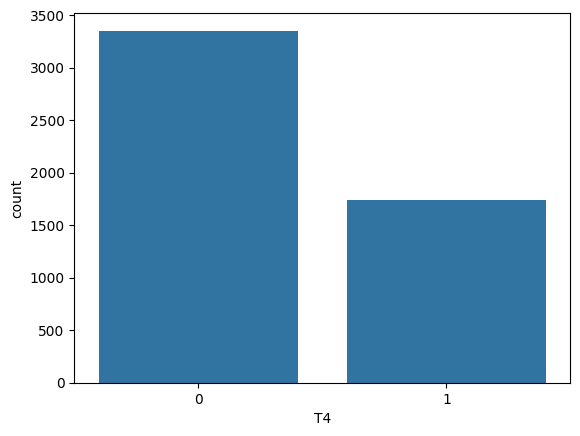

In [7]:
sns.countplot(data, x='T4')
plt.show()

Unemployment duration differences across treatment status are not as obvious as in the 401(k) example:

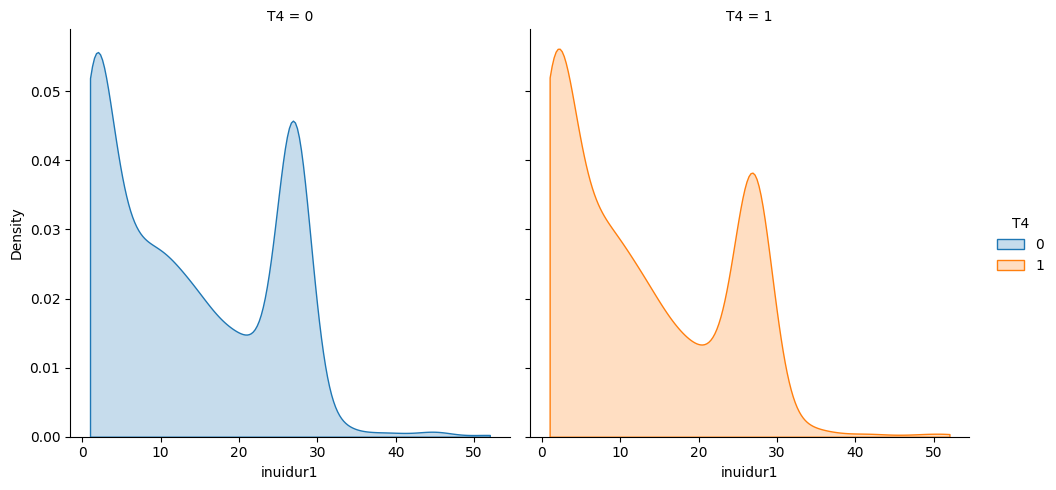

In [8]:
sns.displot(
    data=data,
    x="inuidur1",
    kind="kde",
    col="T4",
    hue="T4",
    fill=True,
    common_norm=False,   # each subgroup KDE integrates to 1
    cut=0,               # avoid extending below support, since unemployment duration is positive (not in logs yet)
)
plt.show()

The unconditional difference in mean unemployment duration is:

In [9]:
e1 = data[data['T4'] == 1]['inuidur1']
e0 = data[data['T4'] == 0]['inuidur1']
print(f'{np.mean(e1) - np.mean(e0):.3f}')

-0.832


The unconditional difference in mean log unemployment duration is:

In [10]:
e1 = np.log(data[data['T4'] == 1]['inuidur1'])
e0 = np.log(data[data['T4'] == 0]['inuidur1'])
log_diff = np.mean(e1) - np.mean(e0)
print(f'{log_diff:.3f} ({100 * (np.exp(log_diff) - 1):.2f}%)')

-0.085 (-8.19%)


As in the 401(k) notebook, we now move from naive differences to orthogonalized DML estimators with flexible nuisance models.

In [11]:
y = np.log(data['inuidur1'].values)
D = data['T4'].values
X = data[['female', 'black', 'othrace', 'dep', 'q2', 'q3', 'q4', 'q5', 'q6',
          'agelt35', 'agegt54', 'durable', 'lusd', 'husd']].copy()
X.columns

Index(['female', 'black', 'othrace', 'dep', 'q2', 'q3', 'q4', 'q5', 'q6',
       'agelt35', 'agegt54', 'durable', 'lusd', 'husd'],
      dtype='str')

### We define a transformer that constructs the engineered features for controls

In [12]:
class FormulaTransformer(TransformerMixin, BaseEstimator):

    def __init__(self, formula, array=False):
        self.formula = formula
        self.array = array

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = Formula(self.formula).get_model_matrix(X)
        if self.array:
            return df.values
        return df

We use the interactions up to second order from the example notebook in chapter 2.

In [13]:
transformer = FormulaTransformer("0 + (female + black + othrace + C(dep) + q2 + q3 + q4 + q5 + q6 "
                                 "+ agelt35 + agegt54 + durable + lusd + husd)**2")

In [14]:
transformer.fit_transform(X).describe()

,female,black,othrace,C(dep)[0],C(dep)[1],C(dep)[2],q2,q3,q4,q5,...,agelt35:agegt54,agelt35:durable,agelt35:lusd,agelt35:husd,agegt54:durable,agegt54:lusd,agegt54:husd,durable:lusd,durable:husd,lusd:husd
count,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,...,5099.0,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.000000,5099.0
mean,0.404001,0.121985,0.007256,0.724064,0.112179,0.163758,0.203765,0.235536,0.225927,0.259070,...,0.0,0.072171,0.132183,0.125319,0.018043,0.031967,0.026476,0.054324,0.028045,0.0
std,0.490746,0.327300,0.084883,0.447029,0.315617,0.370092,0.402836,0.424375,0.418232,0.438167,...,0.0,0.258796,0.338723,0.331112,0.133119,0.175930,0.160561,0.226679,0.165117,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


In [15]:
transformer = FormulaTransformer("0 + (female + black + othrace + C(dep) + q2 + q3 + q4 + q5 + q6 "
                                 "+ agelt35 + agegt54 + durable + lusd + husd)**2", array=True)

## Estimating the ATE of Penn reemployment bonus assignment on log unemployment duration

We are interested in valid estimators of the average treatment effect of `T4` on `log(inuidur1)`. We start by using ML to estimate nuisance functions $g_0$ and $m_0$ in the same PLR setup used in the 401(k) notebook:

$ Y = D\theta_0 + g_0(X) + \zeta,    E[\zeta \mid D,X]= 0$

$D = m_0(X) +  V,    E[V \mid X] = 0.$

### Double ML in PLR with Cross-Fitting

We define a simple dml function that is parameterized by arbitrary ML models and returns the treatment effect and other useful quantities of the analysis

In [16]:
def dml(X, D, y, modely, modeld, *, nfolds, classifier=False):
    '''
    DML for the Partially Linear Model setting with cross-fitting

    Input
    -----
    X: the controls
    D: the treatment
    y: the outcome
    modely: the ML model for predicting the outcome y
    modeld: the ML model for predicting the treatment D
    nfolds: the number of folds in cross-fitting
    classifier: bool, whether the modeld is a classifier or a regressor

    Output
    ------
    point: the point estimate of the treatment effect of D on y
    stderr: the standard error of the treatment effect
    yhat: the cross-fitted predictions for the outcome y
    Dhat: the cross-fitted predictions for the treatment D
    resy: the outcome residuals
    resD: the treatment residuals
    epsilon: the final residual-on-residual OLS regression residual
    '''
    cv = KFold(n_splits=nfolds, shuffle=True, random_state=123)  # shuffled k-folds
    yhat = cross_val_predict(modely, X, y, cv=cv, n_jobs=-1)  # out-of-fold predictions for y
    # out-of-fold predictions for D
    # use predict or predict_proba dependent on classifier or regressor for D
    if classifier:
        Dhat = cross_val_predict(modeld, X, D, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    else:
        Dhat = cross_val_predict(modeld, X, D, cv=cv, n_jobs=-1)
    # calculate outcome and treatment residuals
    resy = y - yhat
    resD = D - Dhat

    # final stage ols based point estimate and standard error
    point = np.mean(resy * resD) / np.mean(resD**2)
    epsilon = resy - point * resD
    var = np.mean(epsilon**2 * resD**2) / np.mean(resD**2)**2
    stderr = np.sqrt(var / X.shape[0])

    return point, stderr, yhat, Dhat, resy, resD, epsilon

In [17]:
def summary(point, stderr, yhat, Dhat, resy, resD, epsilon, X, D, y, *, name):
    '''
    Convenience summary function that takes the results of the DML function
    and summarizes several estimation quantities and performance metrics.
    '''
    return pd.DataFrame({'estimate': point,  # point estimate
                         'stderr': stderr,  # standard error
                         'lower': point - 1.96 * stderr,  # lower end of 95% confidence interval
                         'upper': point + 1.96 * stderr,  # upper end of 95% confidence interval
                         'rmse y': np.sqrt(np.mean(resy**2)),  # RMSE of model that predicts outcome y
                         'rmse D': np.sqrt(np.mean(resD**2)),  # RMSE of model that predicts treatment D
                         'accuracy D': np.mean(np.abs(resD) < .5),  # binary classification accuracy of model for D
                         }, index=[name])

#### Double Lasso with Cross-Fitting

In [18]:
cv = KFold(n_splits=5, shuffle=True, random_state=123)
lassoy = make_pipeline(transformer, StandardScaler(), LassoCV(cv=cv))
lassod = make_pipeline(transformer, StandardScaler(), LassoCV(cv=cv))
result = dml(X, D, y, lassoy, lassod, nfolds=5)

In [19]:
table = summary(*result, X, D, y, name='double lasso')
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,-0.073935,0.035375,-0.143271,-0.004599,1.200337,0.474709,0.657776


#### Using a Penalized Logistic Regression for D

Note the default logistic regression uses an $\ell_2$ penalty. You can use the $\ell_1$ penalty as well, but computation will take longer.

In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=123)
lassoy = make_pipeline(transformer, StandardScaler(), LassoCV(cv=cv))
lgrd = make_pipeline(transformer, StandardScaler(), LogisticRegressionCV(cv=cv))
result = dml(X, D, y, lassoy, lgrd, nfolds=5, classifier=True)

In [21]:
summary(*result, X, D, y, name='lasso/logistic')

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
lasso/logistic,-0.074291,0.035375,-0.143627,-0.004955,1.200337,0.474548,0.65758


In [22]:
table = pd.concat([table, summary(*result, X, D, y, name='lasso/logistic')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,-0.073935,0.035375,-0.143271,-0.004599,1.200337,0.474709,0.657776
lasso/logistic,-0.074291,0.035375,-0.143627,-0.004955,1.200337,0.474548,0.657580


Then, we repeat this procedure for various machine learning methods.

### Random Forests

In [23]:
rfy = make_pipeline(transformer, RandomForestRegressor(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001))
rfd = make_pipeline(transformer, RandomForestClassifier(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001))
result = dml(X, D, y, rfy, rfd, nfolds=5, classifier=True)

In [24]:
table = pd.concat([table, summary(*result, X, D, y, name='random forest')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,-0.073935,0.035375,-0.143271,-0.004599,1.200337,0.474709,0.657776
lasso/logistic,-0.074291,0.035375,-0.143627,-0.004955,1.200337,0.474548,0.657580
random forest,-0.069865,0.035738,-0.139912,0.000182,1.209901,0.474538,0.657776


### Decision Trees

In [25]:
dtry = make_pipeline(transformer, DecisionTreeRegressor(min_samples_leaf=10, ccp_alpha=.001))
dtrd = make_pipeline(transformer, DecisionTreeClassifier(min_samples_leaf=10, ccp_alpha=.001))
result = dml(X, D, y, dtry, dtrd, nfolds=5, classifier=True)

In [26]:
table = pd.concat([table, summary(*result, X, D, y, name='decision tree')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,-0.073935,0.035375,-0.143271,-0.004599,1.200337,0.474709,0.657776
lasso/logistic,-0.074291,0.035375,-0.143627,-0.004955,1.200337,0.474548,0.657580
random forest,-0.069865,0.035738,-0.139912,0.000182,1.209901,0.474538,0.657776
decision tree,-0.064516,0.035961,-0.134999,0.005967,1.219220,0.475057,0.657776


### Boosted Trees

In [27]:
gbfy = make_pipeline(transformer, GradientBoostingRegressor(max_depth=2, n_iter_no_change=5))
gbfd = make_pipeline(transformer, GradientBoostingClassifier(max_depth=2, n_iter_no_change=5))
result = dml(X, D, y, gbfy, gbfd, nfolds=5, classifier=True)

In [28]:
table = pd.concat([table, summary(*result, X, D, y, name='boosted forest')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,-0.073935,0.035375,-0.143271,-0.004599,1.200337,0.474709,0.657776
lasso/logistic,-0.074291,0.035375,-0.143627,-0.004955,1.200337,0.474548,0.657580
random forest,-0.069865,0.035738,-0.139912,0.000182,1.209901,0.474538,0.657776
decision tree,-0.064516,0.035961,-0.134999,0.005967,1.219220,0.475057,0.657776
boosted forest,-0.071943,0.035511,-0.141545,-0.002341,1.204283,0.474771,0.657384


The best model with lowest RMSE Y is lasso, in RMSE D is random forest.

## Issue:
Unfortunately, the following packages do not run locally on my machine. I confirmed with Parker to omit them.

### AutoML

In [29]:
!pip install flaml

In [30]:
# from flaml import AutoML
# flamly = make_pipeline(transformer, AutoML(time_budget=100, task='regression', early_stop=True,
#                                            eval_method='cv', n_splits=3, metric='r2', verbose=3))
# flamld = make_pipeline(transformer, AutoML(time_budget=100, task='classification', early_stop=True,
#                                            eval_method='cv', n_splits=3, metric='r2', verbose=3))
# result = dml(X, D, y, flamly, flamld, nfolds=5, classifier=True)

In [31]:
# Cannot use AutoML in a pipeline, so we will skip this one
# table = pd.concat([table, summary(*result, X, D, y, name='automl')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,-0.073935,0.035375,-0.143271,-0.004599,1.200337,0.474709,0.657776
lasso/logistic,-0.074291,0.035375,-0.143627,-0.004955,1.200337,0.474548,0.657580
random forest,-0.069865,0.035738,-0.139912,0.000182,1.209901,0.474538,0.657776
decision tree,-0.064516,0.035961,-0.134999,0.005967,1.219220,0.475057,0.657776
boosted forest,-0.071943,0.035511,-0.141545,-0.002341,1.204283,0.474771,0.657384


# Semi-Cross-Fitting

To avoid the computational cost of performing model selection within each fold (assuming that we don't select among an exponential set of hyperparameters/models in the number of samples), it is ok to perform model selection using all the data and then perform cross-fitting with the selected model.

In [32]:
# flamly = make_pipeline(transformer, AutoML(time_budget=100, task='regression', early_stop=True,
#                                            eval_method='cv', n_splits=3, metric='r2', verbose=0))
# flamld = make_pipeline(transformer, AutoML(time_budget=100, task='classification', early_stop=True,
#                                            eval_method='cv', n_splits=3, metric='r2', verbose=0))

In [33]:
# flamly.fit(X, y)
# besty = make_pipeline(transformer, clone(flamly[-1].best_model_for_estimator(flamly[-1].best_estimator)))

In [34]:
# flamld.fit(X, D)
# bestd = make_pipeline(transformer, clone(flamld[-1].best_model_for_estimator(flamld[-1].best_estimator)))

In [35]:
# result = dml(X, D, y, besty, bestd, nfolds=5, classifier=True)

In [36]:
# Cannot use AutoML in a pipeline, so we will skip this one
# table = pd.concat([table, summary(*result, X, D, y, name='automl (semi-cfit)')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,-0.073935,0.035375,-0.143271,-0.004599,1.200337,0.474709,0.657776
lasso/logistic,-0.074291,0.035375,-0.143627,-0.004955,1.200337,0.474548,0.657580
random forest,-0.069865,0.035738,-0.139912,0.000182,1.209901,0.474538,0.657776
decision tree,-0.064516,0.035961,-0.134999,0.005967,1.219220,0.475057,0.657776
boosted forest,-0.071943,0.035511,-0.141545,-0.002341,1.204283,0.474771,0.657384


### Semi-Crossfitting with Stacking

In [37]:
def dml_dirty(X, D, y, modely_list, modeld_list, *,
              stacker=LinearRegression(), nfolds, classifier=False):
    '''
    DML for the Partially Linear Model setting with semi-cross-fitting

    Input
    -----
    X: the controls
    D: the treatment
    y: the outcome
    modely: the ML model for predicting the outcome y
    modeld: the ML model for predicting the treatment D
    stacker: model used to aggregate predictions of each of the base models
    nfolds: the number of folds in cross-fitting
    classifier: bool, whether the modeld is a classifier or a regressor

    Output
    ------
    point: the point estimate of the treatment effect of D on y
    stderr: the standard error of the treatment effect
    yhat: the cross-fitted predictions for the outcome y
    Dhat: the cross-fitted predictions for the treatment D
    resy: the outcome residuals
    resD: the treatment residuals
    epsilon: the final residual-on-residual OLS regression residual
    '''
    # construct out-of-fold predictions for each model
    cv = KFold(n_splits=nfolds, shuffle=True, random_state=123)
    yhats = np.array([cross_val_predict(modely, X, y, cv=cv, n_jobs=-1) for modely in modely_list]).T
    if classifier:
        Dhats = np.array([cross_val_predict(modeld, X, D, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
                         for modeld in modeld_list]).T
    else:
        Dhats = np.array([cross_val_predict(modeld, X, D, cv=cv, n_jobs=-1) for modeld in modeld_list]).T
    # calculate stacked residuals by finding optimal coefficients
    # and weigthing out-of-sample predictions by these coefficients
    yhat = stacker.fit(yhats, y).predict(yhats)
    Dhat = stacker.fit(Dhats, D).predict(Dhats)
    resy = y - yhat
    resD = D - Dhat
    # go with the stacked residuals
    point = np.mean(resy * resD) / np.mean(resD**2)
    epsilon = resy - point * resD
    var = np.mean(epsilon**2 * resD**2) / np.mean(resD**2)**2
    stderr = np.sqrt(var / X.shape[0])
    return point, stderr, yhat, Dhat, resy, resD, epsilon

In [38]:
result = dml_dirty(X, D, y, [lassoy, rfy, dtry, gbfy], [lgrd, rfd, dtrd, gbfd],
                   nfolds=5, classifier=True)

In [39]:
table = pd.concat([table, summary(*result, X, D, y, name='stacked (semi-cfit)')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,-0.073935,0.035375,-0.143271,-0.004599,1.200337,0.474709,0.657776
lasso/logistic,-0.074291,0.035375,-0.143627,-0.004955,1.200337,0.474548,0.657580
random forest,-0.069865,0.035738,-0.139912,0.000182,1.209901,0.474538,0.657776
decision tree,-0.064516,0.035961,-0.134999,0.005967,1.219220,0.475057,0.657776
boosted forest,-0.071943,0.035511,-0.141545,-0.002341,1.204283,0.474771,0.657384
stacked (semi-cfit),-0.078188,0.035429,-0.147630,-0.008746,1.199740,0.474148,0.657776


## Interactive Regression Model (IRM)

Next, we consider estimation of average treatment effects when treatment effects are fully heterogeneous:

 $Y  = g_0(D, X) + U,   \quad E[U \mid X, D]= 0,$
 
  $D  = m_0(X) + V,   \quad  E[V\mid X] = 0.$

To reduce the disproportionate impact of extreme propensity score weights in the interactive model
we trim the propensity scores which are below .01 or above .99.

In [40]:
def dr(X, D, y, modely0, modely1, modeld, *, trimming=0.01, nfolds):
    '''
    DML for the Interactive Regression Model setting (Doubly Robust Learning)
    with cross-fitting

    Input
    -----
    X: the controls
    D: the treatment
    y: the outcome
    modely0: the ML model for predicting the outcome y in the control population
    modely1: the ML model for predicting the outcome y in the treated population
    modeld: the ML model for predicting the treatment D
    trimming: threshold below which to trim propensities
    nfolds: the number of folds in cross-fitting

    Output
    ------
    point: the point estimate of the treatment effect of D on y
    stderr: the standard error of the treatment effect
    yhat: the cross-fitted predictions for the outcome y
    Dhat: the cross-fitted predictions for the outcome D
    resy: the outcome residuals
    resD: the treatment residuals
    drhat: the doubly robust quantity for each sample
    '''
    cv = KFold(n_splits=nfolds, shuffle=True, random_state=123)
    yhat0, yhat1 = np.zeros(y.shape), np.zeros(y.shape)
    # we will fit a model E[Y| D, X] by fitting a separate model for D==0
    # and a separate model for D==1.
    for train, test in cv.split(X, y):
        # train a model on training data that received treatment zero and predict on all data in test set
        yhat0[test] = clone(modely0).fit(X.iloc[train][D[train] == 0], y[train][D[train] == 0]).predict(X.iloc[test])
        # train a model on training data that received treatment one and predict on all data in test set
        yhat1[test] = clone(modely1).fit(X.iloc[train][D[train] == 1], y[train][D[train] == 1]).predict(X.iloc[test])
    # prediction for observed treatment
    yhat = yhat0 * (1 - D) + yhat1 * D
    # propensity scores
    Dhat = cross_val_predict(modeld, X, D, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    Dhat = np.clip(Dhat, trimming, 1 - trimming)
    # doubly robust quantity for every sample
    drhat = yhat1 - yhat0 + (y - yhat) * (D / Dhat - (1 - D) / (1 - Dhat))
    point = np.mean(drhat)
    var = np.var(drhat)
    stderr = np.sqrt(var / X.shape[0])
    return point, stderr, yhat, Dhat, y - yhat, D - Dhat, drhat

**NB**: There is randomness across the random seed that potentially causes instability in our estimates. In particular, we find that the lasso/logistic specification for the IRM model exhibits great instability across different seeds. To mitigate these differences, we can take an average across seeds. In principle we would do this for all estimates, but for computation and simplicity, we cheat a little bit and do it only for the model specification we know varies significantly.

In [41]:
cv = KFold(n_splits=5, shuffle=True, random_state=123)
lassoytest = make_pipeline(transformer, StandardScaler(), LassoCV(cv=cv))
lgrdtest = make_pipeline(transformer, StandardScaler(), LogisticRegressionCV(cv=cv))
result = dr(X, D, y, lassoytest, lassoytest, lgrdtest, nfolds=5)
seed_estimates = summary(*result, X, D, y, name='lasso/logistic')

for i in range(9):
    cv = KFold(n_splits=5, shuffle=True, random_state=i)
    lassoytest = make_pipeline(transformer, StandardScaler(), LassoCV(cv=cv))
    lgrdtest = make_pipeline(transformer, StandardScaler(), LogisticRegressionCV(cv=cv))
    result = dr(X, D, y, lassoytest, lassoytest, lgrdtest, nfolds=5)
    seed_estimates = pd.concat([seed_estimates, summary(*result, X, D, y, name='lasso/logistic')])

seed_estimates

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
lasso/logistic,-0.074431,0.035539,-0.144088,-0.004775,1.204662,0.474548,0.657580
lasso/logistic,-0.072524,0.035689,-0.142473,-0.002574,1.207161,0.474657,0.657972
lasso/logistic,-0.073811,0.035658,-0.143701,-0.003922,1.206418,0.474521,0.658168
lasso/logistic,-0.073697,0.035553,-0.143380,-0.004014,1.205111,0.474553,0.657776
lasso/logistic,-0.073169,0.035501,-0.142752,-0.003586,1.205531,0.474569,0.657776
lasso/logistic,-0.072848,0.035466,-0.142362,-0.003334,1.204411,0.474570,0.657776
lasso/logistic,-0.073602,0.035760,-0.143692,-0.003512,1.207744,0.474772,0.658168
lasso/logistic,-0.072588,0.035663,-0.142488,-0.002688,1.204447,0.474631,0.658168
lasso/logistic,-0.074397,0.035972,-0.144902,-0.003891,1.207485,0.475069,0.658168
lasso/logistic,-0.072979,0.035450,-0.142460,-0.003498,1.204673,0.474569,0.657776


As we can see, using lasso and logistic regression for $Y$ and $D$ respectively leads to estimates that vary across different seeds. Letting $\hat{\theta}_s$ denote the vector of $s=10$ estimates across the seeds, we take $$\hat{\theta} := \text{median}(\hat{\theta}_s)$$ and $$SE(\hat{\theta}) := \sqrt{\text{median}\left(SE(\hat{\theta}_s)^2 + (\hat{\theta}_s - \hat{\theta})^2\right)}$$ (Note in the standard error calculation, the operation of de-medianing $\hat{\theta}_s - \hat{\theta}$ is broadcasted.)

In [42]:
med_theta = np.median(seed_estimates.values[:, 0])
se_med = np.sqrt(np.median((seed_estimates.values[:, 1])**2 + (seed_estimates.values[:, 0] - med_theta)**2))
tabledr = pd.DataFrame({'estimate': med_theta,
                        'stderr': se_med,
                        'lower': med_theta - 1.96 * se_med,
                        'upper': med_theta + 1.96 * se_med,
                        'rmse y': np.median(seed_estimates.values[:, 4]),
                        'rmse D': np.median(seed_estimates.values[:, 5]),
                        'accuracy D': np.median(seed_estimates.values[:, 6]),
                        }, index=['lasso/logistic'])

In [43]:
rfy = make_pipeline(transformer, RandomForestRegressor(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001))
rfd = make_pipeline(transformer, RandomForestClassifier(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001))
result = dr(X, D, y, rfy, rfy, rfd, nfolds=5)

In [44]:
tabledr = pd.concat([tabledr, summary(*result, X, D, y, name='random forest')])
tabledr

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
lasso/logistic,-0.073385,0.035608,-0.143176,-0.003595,1.205321,0.474569,0.657874
random forest,-0.068625,0.035744,-0.138684,0.001434,1.215468,0.474628,0.657776


In [45]:
dtry = make_pipeline(transformer, DecisionTreeRegressor(min_samples_leaf=10, ccp_alpha=.001))
dtrd = make_pipeline(transformer, DecisionTreeClassifier(min_samples_leaf=10, ccp_alpha=.001))
result = dr(X, D, y, dtry, dtry, dtrd, nfolds=5)

In [46]:
tabledr = pd.concat([tabledr, summary(*result, X, D, y, name='decision tree')])
tabledr

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
lasso/logistic,-0.073385,0.035608,-0.143176,-0.003595,1.205321,0.474569,0.657874
random forest,-0.068625,0.035744,-0.138684,0.001434,1.215468,0.474628,0.657776
decision tree,-0.059230,0.036273,-0.130325,0.011866,1.242195,0.475057,0.657776


In [47]:
gbfy = make_pipeline(transformer, GradientBoostingRegressor(max_depth=2, n_iter_no_change=5))
gbfd = make_pipeline(transformer, GradientBoostingClassifier(max_depth=2, n_iter_no_change=5))
result = dr(X, D, y, gbfy, gbfy, gbfd, nfolds=5)

In [48]:
tabledr = pd.concat([tabledr, summary(*result, X, D, y, name='boosted forest')])
tabledr

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
lasso/logistic,-0.073385,0.035608,-0.143176,-0.003595,1.205321,0.474569,0.657874
random forest,-0.068625,0.035744,-0.138684,0.001434,1.215468,0.474628,0.657776
decision tree,-0.059230,0.036273,-0.130325,0.011866,1.242195,0.475057,0.657776
boosted forest,-0.077466,0.035674,-0.147386,-0.007546,1.207285,0.474923,0.656599


Across learners, the Penn DML estimates remain in a fairly tight range and are consistent with reduced unemployment duration under treatment assignment.


# Semi-Cross-Fitting
Still doesnt work

In [49]:
# from flaml import AutoML
# flamly0 = make_pipeline(transformer, AutoML(time_budget=60, task='regression', early_stop=True,
#                                             eval_method='cv', n_splits=3, metric='r2', verbose=0))
# flamly1 = make_pipeline(transformer, AutoML(time_budget=60, task='regression', early_stop=True,
#                                             eval_method='cv', n_splits=3, metric='r2', verbose=0))
# flamld = make_pipeline(transformer, AutoML(time_budget=60, task='classification', early_stop=True,
#                                            eval_method='cv', n_splits=3, metric='r2', verbose=0))

In [50]:
# flamly0.fit(X[D == 0], y[D == 0])
# besty0 = make_pipeline(transformer, clone(flamly0[-1].best_model_for_estimator(flamly0[-1].best_estimator)))

In [51]:
# flamly1.fit(X[D == 1], y[D == 1])
# besty1 = make_pipeline(transformer, clone(flamly1[-1].best_model_for_estimator(flamly1[-1].best_estimator)))

In [52]:
# flamld.fit(X, D)
# bestd = make_pipeline(transformer, clone(flamld[-1].best_model_for_estimator(flamld[-1].best_estimator)))

In [53]:
# result = dr(X, D, y, besty0, besty1, bestd, nfolds=5)

In [54]:
# tabledr = pd.concat([tabledr, summary(*result, X, D, y, name='automl (semi-cfit)')])
# tabledr

In [55]:
def dr_dirty(X, D, y, modely0_list, modely1_list, modeld_list, *,
             stacker=LinearRegression(), trimming=0.01, nfolds):
    '''
    DML for the Interactive Regression Model setting (Doubly Robust Learning)
    with cross-fitting

    Input
    -----
    X: the controls
    D: the treatment
    y: the outcome
    modely_list: list of ML models for predicting the outcome y
    modeld_list: list of ML models for predicting the treatment D
    stacker: model used to aggregate predictions of each of the base models
    trimming: threshold below which to trim propensities
    nfolds: the number of folds in cross-fitting

    Output
    ------
    point: the point estimate of the treatment effect of D on y
    stderr: the standard error of the treatment effect
    yhat: the cross-fitted predictions for the outcome y
    Dhat: the cross-fitted predictions for the outcome D
    resy: the outcome residuals
    resD: the treatment residuals
    drhat: the doubly robust quantity for each sample
    '''
    cv = KFold(n_splits=nfolds, shuffle=True, random_state=123)

    # we will fit a model E[Y| D, X] by fitting a separate model for D==0
    # and a separate model for D==1. We do that for each model type in modely_list
    yhats0, yhats1 = np.zeros((y.shape[0], len(modely0_list))), np.zeros((y.shape[0], len(modely1_list)))
    for train, test in cv.split(X, y):
        for it, modely0 in enumerate(modely0_list):
            mdl = clone(modely0).fit(X.iloc[train][D[train] == 0], y[train][D[train] == 0])
            yhats0[test, it] = mdl.predict(X.iloc[test])
        for it, modely1 in enumerate(modely1_list):
            mdl = clone(modely1).fit(X.iloc[train][D[train] == 1], y[train][D[train] == 1])
            yhats1[test, it] = mdl.predict(X.iloc[test])

    # calculate stacking weights for the outcome model for each population
    # and combine the outcome model predictions
    yhat0 = clone(stacker).fit(yhats0[D == 0], y[D == 0]).predict(yhats0)
    yhat1 = clone(stacker).fit(yhats1[D == 1], y[D == 1]).predict(yhats1)

    # prediction for observed treatment using the stacked model
    yhat = yhat0 * (1 - D) + yhat1 * D

    # propensity scores
    Dhats = np.array([cross_val_predict(modeld, X, D, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
                     for modeld in modeld_list]).T
    # construct coefficients on each model based on stacker
    Dhat = clone(stacker).fit(Dhats, D).predict(Dhats)
    # trim propensities
    Dhat = np.clip(Dhat, trimming, 1 - trimming)

    # doubly robust quantity for every sample
    drhat = yhat1 - yhat0 + (y - yhat) * (D / Dhat - (1 - D) / (1 - Dhat))
    point = np.mean(drhat)
    var = np.var(drhat)
    stderr = np.sqrt(var / X.shape[0])
    return point, stderr, yhat, Dhat, y - yhat, D - Dhat, drhat

In [56]:
result = dr_dirty(X, D, y, [lassoy, rfy, dtry, gbfy], [lassoy, rfy, dtry, gbfy], [lgrd, rfd, dtrd, gbfd], nfolds=5)

In [57]:
tabledr = pd.concat([tabledr, summary(*result, X, D, y, name='stacked (semi-cfit)')])
tabledr

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
lasso/logistic,-0.073385,0.035608,-0.143176,-0.003595,1.205321,0.474569,0.657874
random forest,-0.068625,0.035744,-0.138684,0.001434,1.215468,0.474628,0.657776
decision tree,-0.059230,0.036273,-0.130325,0.011866,1.242195,0.475057,0.657776
boosted forest,-0.077466,0.035674,-0.147386,-0.007546,1.207285,0.474923,0.656599
stacked (semi-cfit),-0.082602,0.035510,-0.152201,-0.013002,1.202160,0.473955,0.657580


We can compare the results between the PLR model and IRM model. We find that the effect under the IRM model is typically of lower value.

In [58]:
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,-0.073935,0.035375,-0.143271,-0.004599,1.200337,0.474709,0.657776
lasso/logistic,-0.074291,0.035375,-0.143627,-0.004955,1.200337,0.474548,0.657580
random forest,-0.069865,0.035738,-0.139912,0.000182,1.209901,0.474538,0.657776
decision tree,-0.064516,0.035961,-0.134999,0.005967,1.219220,0.475057,0.657776
boosted forest,-0.071943,0.035511,-0.141545,-0.002341,1.204283,0.474771,0.657384
stacked (semi-cfit),-0.078188,0.035429,-0.147630,-0.008746,1.199740,0.474148,0.657776


In [59]:
tabledr

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
lasso/logistic,-0.073385,0.035608,-0.143176,-0.003595,1.205321,0.474569,0.657874
random forest,-0.068625,0.035744,-0.138684,0.001434,1.215468,0.474628,0.657776
decision tree,-0.059230,0.036273,-0.130325,0.011866,1.242195,0.475057,0.657776
boosted forest,-0.077466,0.035674,-0.147386,-0.007546,1.207285,0.474923,0.656599
stacked (semi-cfit),-0.082602,0.035510,-0.152201,-0.013002,1.202160,0.473955,0.657580


# Using the EconML Library
Same issue applies here that I cannot run the code, but implementation would not change anyway.


We can also run PLR and IRM-style estimators using external libraries such as `EconML` and `DoubleML`, now with Penn variables `D=T4` and `y=log(inuidur1)`.


In [60]:
# !pip install econml==0.15.1

In [61]:
# # for these libraries we will just pre-featurize the controls
# W = StandardScaler().fit_transform(transformer.fit_transform(X))

In [62]:
# from econml.dml import LinearDML
# cv = KFold(n_splits=5, shuffle=True, random_state=123)
# ldml = LinearDML(model_y=LassoCV(cv=cv), model_t=LogisticRegressionCV(cv=cv),
#                  cv=5, discrete_treatment=True, random_state=123).fit(y, D, W=W)

In [63]:
# ldml.summary()

In [64]:
# # r2scores
# r2scorey = np.mean(ldml.nuisance_scores_y)
# r2scored = np.mean(ldml.nuisance_scores_t)
# r2scorey, r2scored

In [65]:
# from econml.dr import LinearDRLearner

# # dr learner in econml fits a single regression function of Y from X, D
# # using all the data
# dr = LinearDRLearner(model_regression=LassoCV(cv=cv),
#                      model_propensity=LogisticRegressionCV(cv=cv),
#                      cv=5, min_propensity=0.01, random_state=123).fit(y, D, W=W)

In [66]:
# dr.summary(T=1)

In [67]:
# from econml.dr import LinearDRLearner
# from econml.utilities import SeparateModel

# # to implement the separate regression models we need use the separate model wrapper
# # that splits the data based on the last covariate (in this case D) and fits a separate
# # model for each group. The input to the wrapper is the model to use for each value
# # of the last covariate.
# dr = LinearDRLearner(model_regression=SeparateModel(LassoCV(cv=cv), LassoCV(cv=cv)),
#                      model_propensity=LogisticRegressionCV(cv=cv),
#                      cv=5, min_propensity=0.01, random_state=123).fit(y, D, W=W)

In [68]:
# dr.summary(T=1)

# Using the DoubleML library

We now play with `DoubleML` to illustrate its use.

In [69]:
# !pip install doubleml~=0.7.0

In [70]:
# from doubleml import DoubleMLData
# dml_data = DoubleMLData.from_arrays(W, y, D)
# print(dml_data)

In [71]:
# import doubleml as dml

# dml_plr_obj = dml.DoubleMLPLR(dml_data, LassoCV(cv=cv), LogisticRegressionCV(cv=cv), n_folds=5)
# print(dml_plr_obj.fit())

In [72]:
# dml_irm_obj = dml.DoubleMLIRM(dml_data, LassoCV(cv=cv), LogisticRegressionCV(cv=cv), n_folds=5)

# print(dml_irm_obj.fit())